이건 **보험 고객 이탈(Churn) 예측 데이터셋의 컬럼 설명**이야.
쉽게 말하면 **고객 정보 + 보험 사용 행동 + 결제/클레임 기록을 이용해서 고객이 보험을 해지할지 예측하는 데이터**야.

크게 **6가지 그룹**으로 나눠서 보면 이해가 쉬워.

---

# 1️⃣ 고객 기본 정보 (Customer Profile)

고객의 **기본적인 인적 정보**

| 컬럼                 | 의미                    |
| ------------------ | --------------------- |
| **customer_id**    | 고객 고유 ID              |
| **as_of_date**     | 데이터 기준 날짜             |
| **region_name**    | 고객이 거주하는 지역           |
| **age**            | 고객 나이                 |
| **age_band**       | 나이 구간 (예: 20대, 30대 등) |
| **marital_status** | 결혼 여부                 |

👉 **왜 중요?**
연령, 지역, 결혼 여부에 따라 보험 유지율이 달라질 수 있음.

예

* 젊은 고객 → 보험 해지율 높음
* 가족 있는 고객 → 보험 유지율 높음

---

# 2️⃣ 고객 보험 가입 정보 (Policy Information)

고객이 **보험을 얼마나 오래, 몇 개 가지고 있는지**

| 컬럼                         | 의미                  |
| -------------------------- | ------------------- |
| **customer_tenure_months** | 보험 가입 기간 (개월)       |
| **multi_policy_flag**      | 여러 보험 가입 여부 (1=여러개) |
| **num_policies**           | 보유 보험 개수            |
| **policy_type**            | 주요 보험 종류            |
| **renewal_month**          | 보험 갱신 월             |

👉 **중요 포인트**

보험 데이터에서 **tenure**는 매우 중요한 변수

예

* 가입 1년 미만 → 이탈 확률 높음
* 보험 여러개 → 충성 고객

---

# 3️⃣ 보험료 관련 정보 (Premium Information)

고객이 **얼마를 내고 있는지**

| 컬럼                              | 의미              |
| ------------------------------- | --------------- |
| **current_premium**             | 현재 보험료          |
| **premium_last_year**           | 작년 보험료          |
| **premium_change_pct**          | 보험료 변화율         |
| **num_price_increases_last_3y** | 최근 3년 보험료 인상 횟수 |

👉 핵심 포인트

보험 이탈에서 **가격 상승은 가장 큰 원인**

예

보험료
100만원 → 140만원

→ 고객 이탈 확률 상승

---

# 4️⃣ 보장 및 비용 구조 (Coverage)

보험 보장 규모

| 컬럼                            | 의미            |
| ----------------------------- | ------------- |
| **coverage_amount**           | 보장 금액         |
| **premium_to_coverage_ratio** | 보험료 / 보장금액 비율 |

👉 의미

보험이 **비싸다고 느끼는지** 확인하는 변수

예

보장금액
1000만원

보험료
200만원

→ 비싸다고 느껴서 해지 가능

---

# 5️⃣ 결제 행동 데이터 (Payment Behavior)

고객의 **보험료 납부 행동**

| 컬럼                             | 의미          |
| ------------------------------ | ----------- |
| **payment_frequency**          | 납부 방식 (월/연) |
| **autopay_enabled**            | 자동이체 여부     |
| **late_payment_count_12m**     | 12개월 연체 횟수  |
| **missed_payment_flag**        | 연체 심함 여부    |
| **payment_method_change_flag** | 결제 방식 변경    |

👉 매우 중요한 이탈 신호

예

* 자동이체 해지
* 연체 증가

→ 이탈 전조

---

# 6️⃣ 보험 청구(Claim) 기록

보험을 **얼마나 사용했는지**

| 컬럼                           | 의미            |
| ---------------------------- | ------------- |
| **num_claims_12m**           | 최근 1년 클레임 수   |
| **num_approved_claims_12m**  | 승인된 클레임       |
| **num_rejected_claims_12m**  | 거절된 클레임       |
| **num_pending_claims_12m**   | 처리중 클레임       |
| **avg_claim_amount**         | 평균 청구 금액      |
| **total_claim_amount_12m**   | 총 청구 금액       |
| **total_payout_amount_12m**  | 지급된 보험금       |
| **payout_ratio_12m**         | 지급률           |
| **avg_settlement_time_days** | 보험금 처리 시간     |
| **days_since_last_claim**    | 마지막 청구 이후 경과일 |

👉 중요한 이유

보험에서 **클레임 경험이 안좋으면 이탈**

예

* 클레임 거절
* 지급 늦음

→ 고객 불만 → 해지

---

# 7️⃣ 고객 서비스 및 행동

고객이 **보험사와 얼마나 접촉했는지**

| 컬럼                            | 의미          |
| ----------------------------- | ----------- |
| **num_contacts_12m**          | 고객센터 접촉 횟수  |
| **complaint_flag**            | 불만 제기 여부    |
| **complaint_resolution_days** | 불만 해결 시간    |
| **quote_requested_flag**      | 다른 보험 견적 요청 |
| **coverage_downgrade_flag**   | 보장 축소 여부    |

👉 핵심 이탈 신호

특히

**quote_requested_flag**

이건 거의 **100% 쇼핑 행동**

예

보험 비교 견적 요청
→ 곧 해지 가능성 높음

---

# 8️⃣ 타겟 변수 (Label)

모델이 예측해야 하는 값

| 컬럼                         | 의미                   |
| -------------------------- | -------------------- |
| **churn_flag**             | 이탈 여부 (1=해지)         |
| **churn_type**             | 이탈 이유                |
| **churn_probability_true** | 실제 이탈 확률 (synthetic) |

👉 머신러닝에서

**y 값**

```
y = churn_flag
```

---

# 📊 정리 (데이터 구조)

이 데이터는 **보험 고객 행동 기반 이탈 예측 데이터**

구성

```
고객 정보
   ↓
보험 정보
   ↓
보험료 변화
   ↓
결제 행동
   ↓
클레임 기록
   ↓
고객 행동
   ↓
이탈 여부 (Target)
```


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
policy_df = pd.read_csv('../data/insurance_policyholder_churn_synthetic.csv')

policy_df.head()
policy_df.shape
policy_df.columns
policy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  str    
 2   region_name                  50000 non-null  str    
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  str    
 5   marital_status               50000 non-null  str    
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  str    
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  premium_change_pct         

In [13]:
policy_df['age_band'].value_counts()

age_band
75+      8026
25-34    7448
45-54    7399
65-74    7381
55-64    7340
35-44    7273
18-24    5133
Name: count, dtype: int64

## 가설 6: "나이(Age)가 어릴수록 더 저렴한 보험을 찾아 이동하는 경향이 강해 이탈률이 높을 것이다."

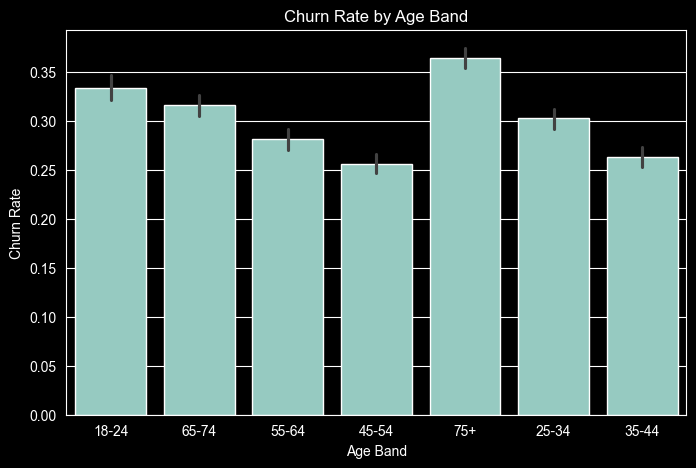

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=policy_df, x='age_band', y='churn_flag')

plt.title("Churn Rate by Age Band")
plt.ylabel("Churn Rate")
plt.xlabel("Age Band")

plt.show()

연령대별 이탈률을 비교한 결과,
18–24세와 25–34세에서 비교적 높은 이탈률이 나타났다.

이는 젊은 고객이 가격에 민감하며
더 저렴한 보험 상품을 찾아 이동할 가능성이 있다는 가설을 부분적으로 지지한다.

다만 75세 이상 고객에서도 높은 이탈률이 나타나,
연령이 높다고 해서 반드시 보험 유지율이 높은 것은 아님을 확인할 수 있었다.

### 1. 젊은 고객이 실제로 보험을 더 많이 비교하는가?

<Axes: xlabel='age_band', ylabel='churn_flag'>

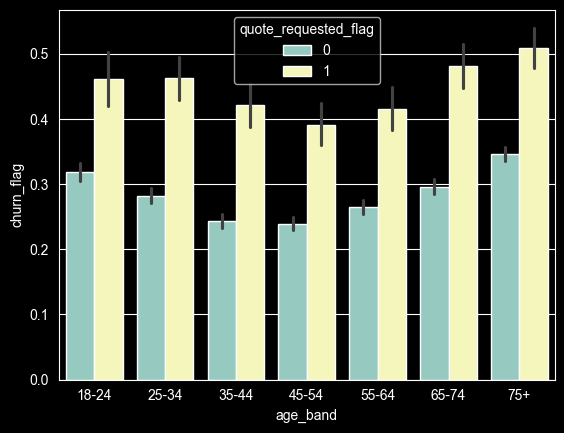

In [15]:
age_order = [
    '18-24',
    '25-34',
    '35-44',
    '45-54',
    '55-64',
    '65-74',
    '75+'
]

sns.barplot(data=policy_df,
            x='age_band',
            y='churn_flag',
            hue='quote_requested_flag',
            order=age_order)

보험 비교 견적 요청 여부에 따른 이탈률을 분석한 결과, 견적 요청을 한 고객은 모든 연령대에서 견적 요청을 하지 않은 고객보다 높은 이탈률을 보였다. 이는 보험 비교 행동이 고객 이탈과 강하게 연관되어 있음을 의미한다.
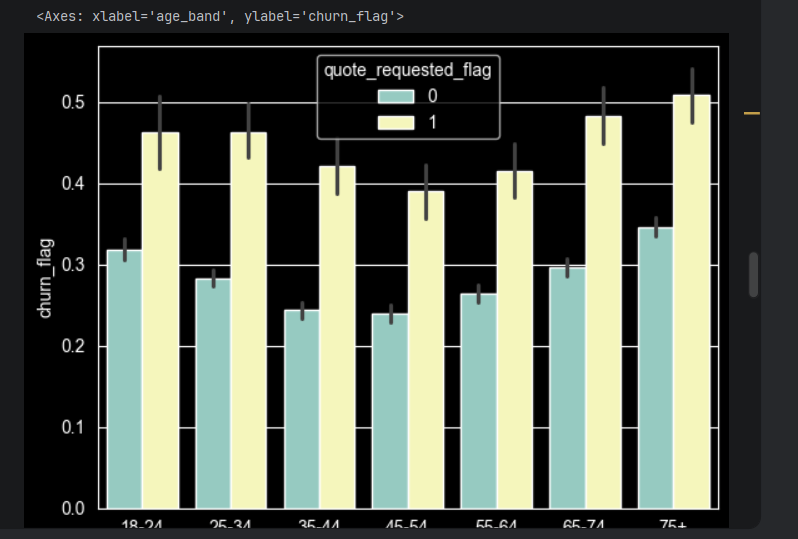

<Axes: xlabel='age_band', ylabel='quote_requested_flag'>

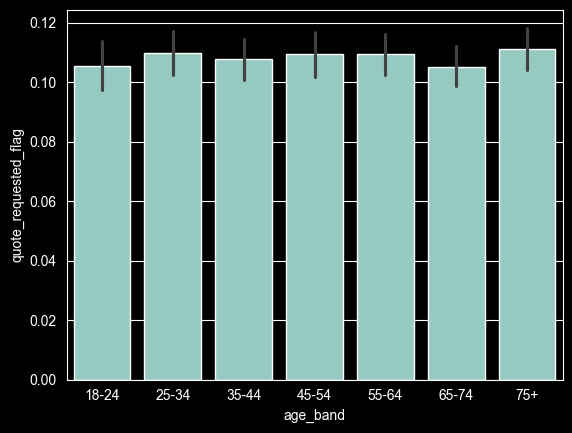

In [16]:
sns.barplot(data=policy_df,
            x='age_band',
            y='quote_requested_flag',
            order=age_order)

젊은 고객이 특별히 더 많이 보험을 비교한다고 보기는 어렵다

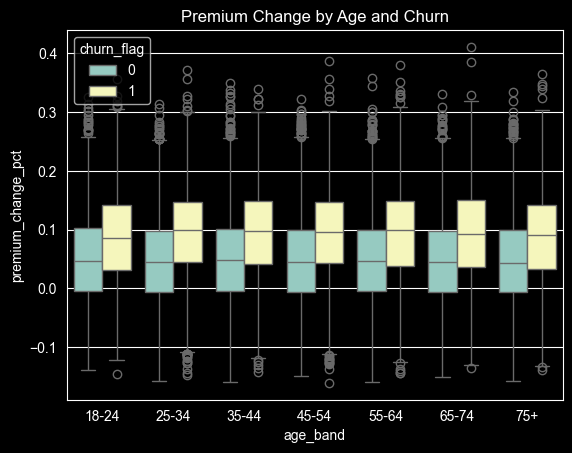

In [17]:
sns.boxplot(data=policy_df,
            x='age_band',
            y='premium_change_pct',
            hue='churn_flag',
            order=age_order)

plt.title("Premium Change by Age and Churn")
plt.show()

연령대별 보험료 변화율과 이탈 여부를 분석한 결과, 모든 연령대에서 보험료 상승률이 높은 고객일수록 이탈률이 증가하는 경향이 나타났다. 그러나 연령대별 보험료 상승 분포는 유사하게 나타나 젊은 고객이 다른 연령대보다 보험료 상승에 더 민감하다고 보기는 어려운 것으로 나타났다.

## 가설 7 :"보험료 연체가 발생한 고객은 보험 이탈 가능성이 높을 것이다.”

<Axes: xlabel='missed_payment_flag', ylabel='churn_flag'>

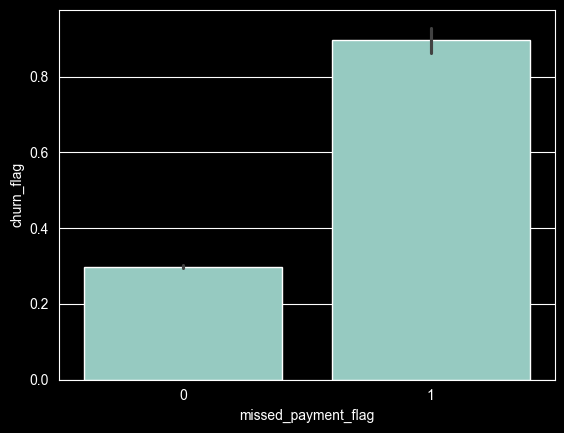

In [18]:
sns.barplot(data=policy_df,
            x='missed_payment_flag',
            y='churn_flag')

보험료 연체 여부에 따른 이탈률을 분석한 결과, 연체가 없는 고객의 이탈률은 약 29%였으나 연체가 발생한 고객의 이탈률은 약 90%로 매우 높게 나타났다. 이는 보험료 연체가 고객의 보험 유지 의지가 크게 약화된 상태를 의미하며, 고객 이탈을 예측하는 중요한 행동 변수임을 보여준다.

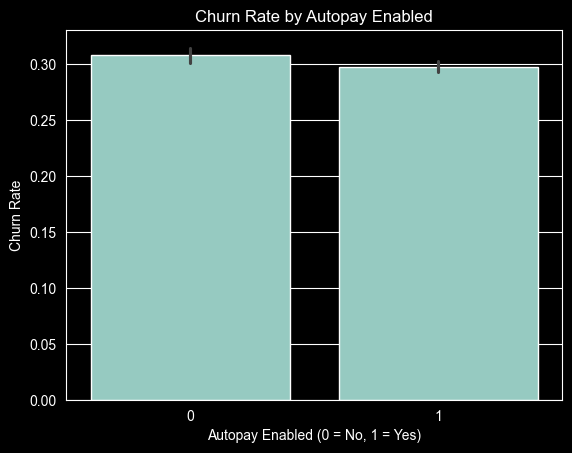

In [19]:
sns.barplot(data=policy_df,
            x='autopay_enabled',
            y='churn_flag')

plt.title("Churn Rate by Autopay Enabled")
plt.xlabel("Autopay Enabled (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate")

plt.show()

자동이체 여부에 따른 이탈률에는 큰영향이 없다.